# Phase 5: Exploratory Data Analysis (EDA)
**Goal:** Formally document the data exploration process, analyze data quality, investigate temporal patterns, and justify the feature engineering decisions (such as lag features) used in the AQI Predictor model.

## 1. Setup and Data Loading
First, we load the historical data directly from the Hopsworks Feature Store (Feature Group V3).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hopsworks
import warnings
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load environment variables
load_dotenv('../.env')

# Connect to Hopsworks
project = hopsworks.login(api_key_value=os.getenv("HOPSWORKS_API_KEY"), project=os.getenv("HOPSWORKS_PROJECT_NAME"))
fs = project.get_feature_store()

# Fetch Feature Group V4
fg = fs.get_feature_group(name="aqi_features", version=4)
df = fg.read()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# Extract temporal features for analysis
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['hour'] = df['timestamp'].dt.hour
df['is_night'] = ((df['hour'] >= 20) | (df['hour'] < 6)).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Temporal columns created: month, day_of_week, hour, is_night")
display(df.head())


2026-06-05 19:56:43,386 INFO: Initializing external client
2026-06-05 19:56:43,386 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-06-05 19:56:46,611 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32893
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (37.16s) 
Dataset shape: (2185, 26)


,city_name,timestamp,hour,day_of_week,month,is_weekend,is_night,temperature,humidity,pressure,...,so2,co,o3,pm25_lag_1h,pm25_lag_6h,pm25_lag_24h,pm25_change_24h,pm25_rolling_mean_24h,temp_trend_6h,pm25
0,islamabad,2026-03-06 00:00:00+00:00,0,4,3,0,1,19.299999,50.281303,945.722839,...,3.5,374.0,17.0,27.000000,51.500000,27.600000,3.699999,36.450000,1.199999,31.299999
1,islamabad,2026-03-06 01:00:00+00:00,1,4,3,0,1,18.950001,49.342899,946.212280,...,4.0,998.0,17.0,31.299999,45.900002,26.400000,1.200001,36.500000,0.500000,27.600000
2,islamabad,2026-03-06 02:00:00+00:00,2,4,3,0,1,18.049999,54.003307,946.398987,...,5.0,1871.0,19.0,27.600000,40.200001,28.600000,1.400000,36.558333,-0.200001,30.000000
3,islamabad,2026-03-06 03:00:00+00:00,3,4,3,0,1,20.750000,53.620758,947.522949,...,7.7,2341.0,30.0,30.000000,35.200001,33.099998,1.400002,36.616667,2.700001,34.500000
4,islamabad,2026-03-06 04:00:00+00:00,4,4,3,0,1,24.200001,43.769398,948.601746,...,14.0,1999.0,56.0,34.500000,31.000000,33.799999,1.100002,36.662500,6.100000,34.900002


## 2. Data Quality & Distribution Checks
Before modeling, we must ensure our target variable (`pm25`) and key features are distributed logically without extreme anomalies.


Missing values per column:
Series([], dtype: int64)


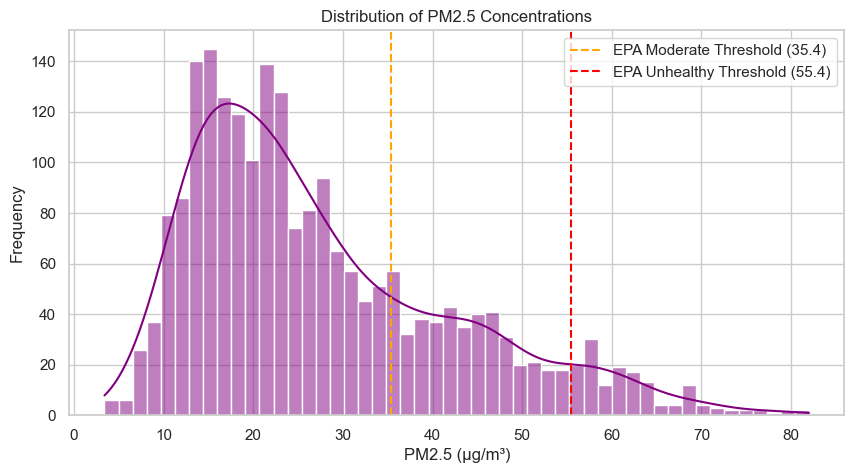

In [3]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

# Plot PM2.5 Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['pm25'], bins=50, kde=True, color='purple')
plt.title('Distribution of PM2.5 Concentrations')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.axvline(x=35.4, color='orange', linestyle='--', label='EPA Moderate Threshold (35.4)')
plt.axvline(x=55.4, color='red', linestyle='--', label='EPA Unhealthy Threshold (55.4)')
plt.legend()
plt.show()


## 3. Temporal Patterns
Air quality is highly dependent on time (e.g., traffic rush hours, night-time atmospheric inversion).


2026-06-05 19:57:43,144 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-05 19:57:43,153 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


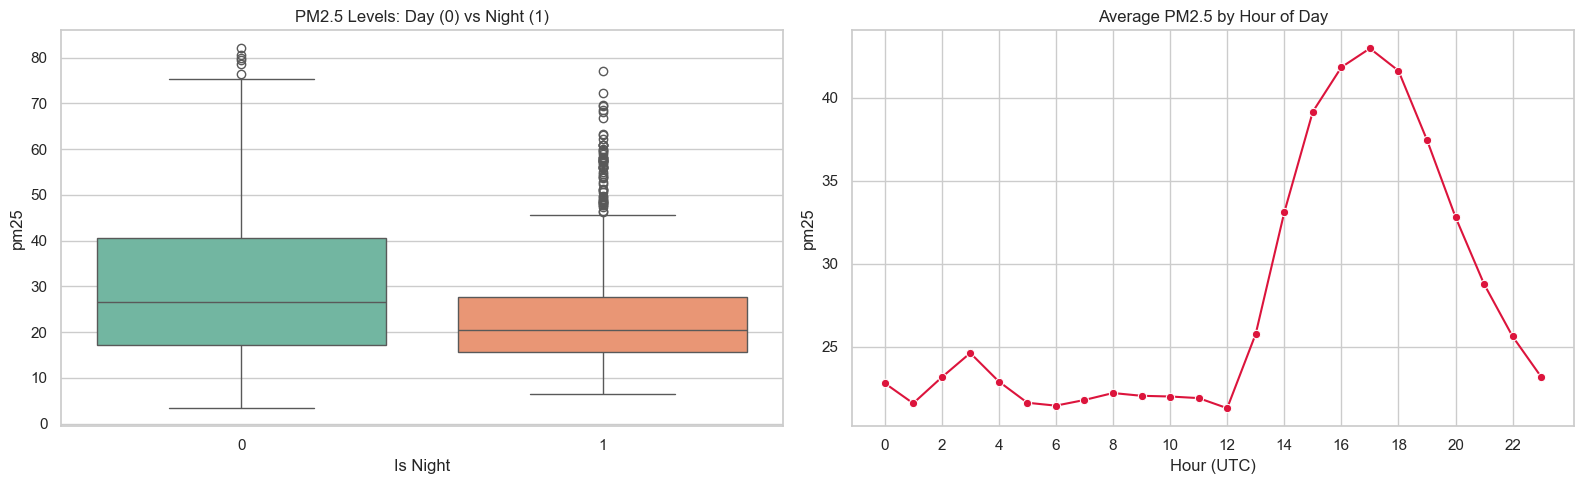

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Day vs Night
sns.boxplot(data=df, x='is_night', y='pm25', ax=axes[0], palette="Set2")
axes[0].set_title('PM2.5 Levels: Day (0) vs Night (1)')
axes[0].set_xlabel('Is Night')

# Hourly trends
hourly_avg = df.groupby('hour')['pm25'].mean().reset_index()
sns.lineplot(data=hourly_avg, x='hour', y='pm25', marker='o', ax=axes[1], color='crimson')
axes[1].set_title('Average PM2.5 by Hour of Day')
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_xlabel('Hour (UTC)')

plt.tight_layout()
plt.show()


## 4. Feature Correlations
How do weather variables (temperature, humidity, wind) and other pollutants interact with PM2.5?


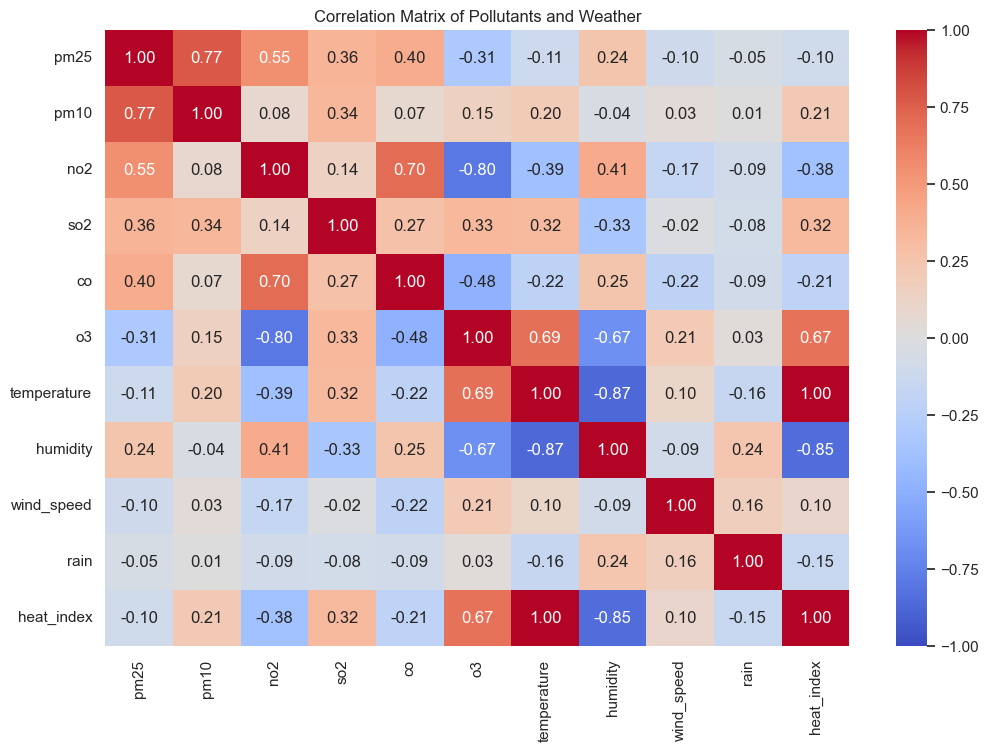

In [5]:
cols_to_correlate = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'rain', 'heat_index']
corr_matrix = df[cols_to_correlate].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Pollutants and Weather')
plt.show()


## 5. Lag Analysis (Autocorrelation)
To justify building a 24-hour forecasting model, we must prove that past PM2.5 values are predictive of future PM2.5 values. We use the Autocorrelation Function (ACF) to show this.


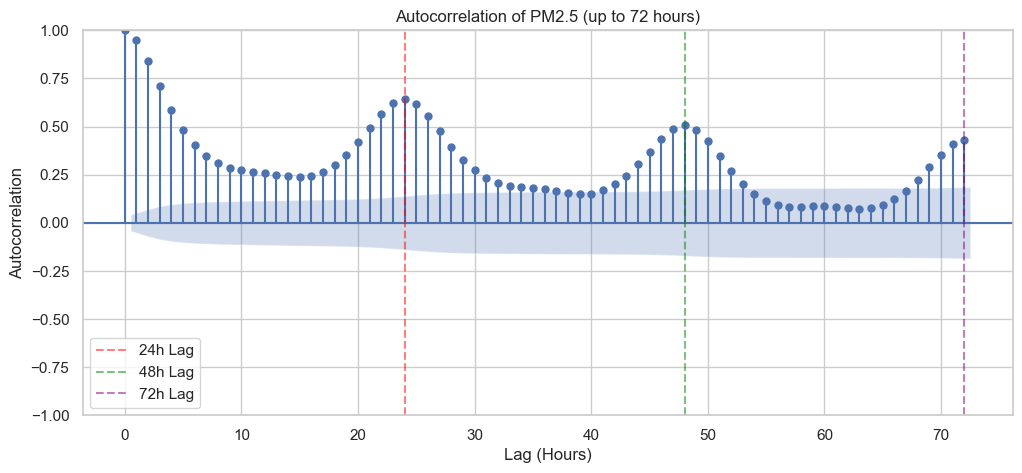

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))
# Plot autocorrelation for up to 72 hours (3 days)
plot_acf(df['pm25'].dropna(), lags=72, alpha=0.05, ax=plt.gca())
plt.title('Autocorrelation of PM2.5 (up to 72 hours)')
plt.xlabel('Lag (Hours)')
plt.ylabel('Autocorrelation')
plt.axvline(x=24, color='red', linestyle='--', alpha=0.5, label='24h Lag')
plt.axvline(x=48, color='green', linestyle='--', alpha=0.5, label='48h Lag')
plt.axvline(x=72, color='purple', linestyle='--', alpha=0.5, label='72h Lag')
plt.legend()
plt.show()


## 6. Conclusions & Modeling Strategy
Based on this EDA:
1. **PM2.5 Distribution**: The data is heavily right-skewed, which is typical for pollutants. Tree-based models (Random Forest, XGBoost) are well-suited for this as they don't require normally distributed targets.
2. **Temporal Patterns**: PM2.5 varies significantly by hour and between day/night. Features like `hour` and `is_night` are critical.
3. **Correlations**: PM10 and CO are highly correlated with PM2.5. Weather variables like wind speed have a slight negative correlation (wind disperses pollutants).
4. **Autocorrelation**: There is a massive spike in autocorrelation every 24 hours (24h, 48h, 72h). This **proves** that adding `pm25_lag_24h` is mathematically sound, and supports our upcoming expansion to a 3-day (+24h, +48h, +72h) forecasting architecture.


## 7. Summary Statistics & Data Quality
Overview of dataset size, date ranges, and statistical summaries.


In [7]:
# Dataset Overview
print("="*70)
print("DATASET SUMMARY STATISTICS")
print("="*70)
print(f"\nDataset Shape: {df.shape}")
print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
print(f"\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\n\nKey Features Statistics:")
print(df[['pm25', 'pm10', 'temperature', 'humidity', 'wind_speed', 'rain']].describe())

# Memory usage
print(f"\n\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


DATASET SUMMARY STATISTICS

Dataset Shape: (2185, 26)
Date Range: 2026-03-06 00:00:00+00:00 to 2026-06-05 23:00:00+00:00
Duration: 91 days

Missing Values:
Series([], dtype: int64)


Key Features Statistics:
              pm25         pm10  temperature     humidity   wind_speed  \
count  2185.000000  2185.000000  2185.000000  2185.000000  2185.000000   
mean     27.577025    48.800412    22.629245    56.961552     6.026668   
std      14.737972    35.414987     6.231771    18.912532     3.285607   
min       3.400000     4.800000     9.800000    15.396835     0.000000   
25%      16.400000    25.799999    17.750000    41.988316     3.852168   
50%      23.200001    37.799999    22.549999    57.684505     5.402999   
75%      35.900002    60.099998    27.000000    70.838890     7.562142   
max      82.000000   338.100006    38.000000    98.699646    25.376808   

              rain  
count  2185.000000  
mean      0.119954  
std       0.601521  
min       0.000000  
25%       0.000000  

## 8. Seasonality Analysis
Does PM2.5 vary by season/month? This reveals recurring pollution patterns.


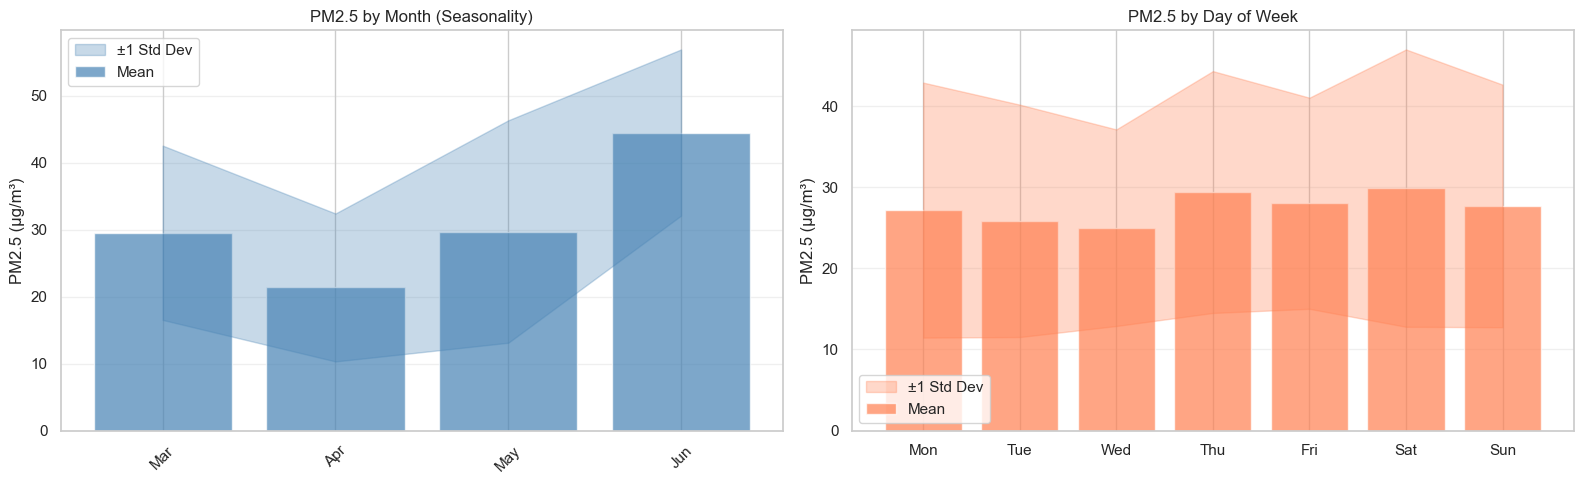

Seasonal Insights:
  Highest pollution month: Jun (44.51 µg/m³)
  Lowest pollution month: Apr (21.37 µg/m³)
  Most polluted day: Sat (29.89 µg/m³)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Extract temporal features if not already present
if 'month' not in df.columns:
    df['month'] = df['timestamp'].dt.month
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['timestamp'].dt.dayofweek

# Monthly seasonality
monthly_stats = df.groupby('month')['pm25'].agg(['mean', 'std'])
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0].bar(range(1, len(monthly_stats) + 1), monthly_stats['mean'], color='steelblue', alpha=0.7, label='Mean')
axes[0].fill_between(range(1, len(monthly_stats) + 1), 
                      monthly_stats['mean'] - monthly_stats['std'],
                      monthly_stats['mean'] + monthly_stats['std'],
                      alpha=0.3, color='steelblue', label='±1 Std Dev')
axes[0].set_xticks(range(1, len(monthly_stats) + 1))
axes[0].set_xticklabels([months[i-1] for i in monthly_stats.index], rotation=45)
axes[0].set_title('PM2.5 by Month (Seasonality)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Day of week
dow_stats = df.groupby('day_of_week')['pm25'].agg(['mean', 'std'])
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(len(dow_stats)), dow_stats['mean'], color='coral', alpha=0.7, label='Mean')
axes[1].fill_between(range(len(dow_stats)),
                      dow_stats['mean'] - dow_stats['std'],
                      dow_stats['mean'] + dow_stats['std'],
                      alpha=0.3, color='coral', label='±1 Std Dev')
axes[1].set_xticks(range(len(dow_stats)))
axes[1].set_xticklabels([days[i] if i < len(days) else f'Day {i}' for i in dow_stats.index])
axes[1].set_title('PM2.5 by Day of Week')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Seasonal Insights:")
print(f"  Highest pollution month: {months[monthly_stats['mean'].idxmax()-1]} ({monthly_stats['mean'].max():.2f} µg/m³)")
print(f"  Lowest pollution month: {months[monthly_stats['mean'].idxmin()-1]} ({monthly_stats['mean'].min():.2f} µg/m³)")
print(f"  Most polluted day: {days[dow_stats['mean'].idxmax()]} ({dow_stats['mean'].max():.2f} µg/m³)")


## 9. Outlier Detection & Anomalies
Identify extreme pollution events that may skew training.



OUTLIER ANALYSIS (IQR Method)
Lower Bound: -12.85 µg/m³
Upper Bound: 65.15 µg/m³
Total Outliers: 37 (1.69%)

Extreme Pollution Events (Top 10):
                     timestamp       pm25  temperature   humidity  wind_speed
2060 2026-05-30 20:00:00+00:00  82.000000    23.750000  70.210663    1.659518
1627 2026-05-12 19:00:00+00:00  80.599998    23.400000  60.990051    5.220000
1626 2026-05-12 18:00:00+00:00  79.900002    23.799999  59.347179    5.506941
2059 2026-05-30 19:00:00+00:00  79.400002    24.150000  69.192146    1.310420
2051 2026-05-30 11:00:00+00:00  78.500000    29.549999  39.662273    6.048107
2061 2026-05-30 21:00:00+00:00  77.099998    23.400000  71.932938    0.763675
2119 2026-06-02 07:00:00+00:00  76.400002    32.250000  41.440342    4.792870
1628 2026-05-12 20:00:00+00:00  75.400002    23.049999  63.096760    3.818376
2058 2026-05-30 18:00:00+00:00  74.300003    24.700001  64.877342    4.379589
1625 2026-05-12 17:00:00+00:00  74.000000    23.549999  57.967865    5.0432

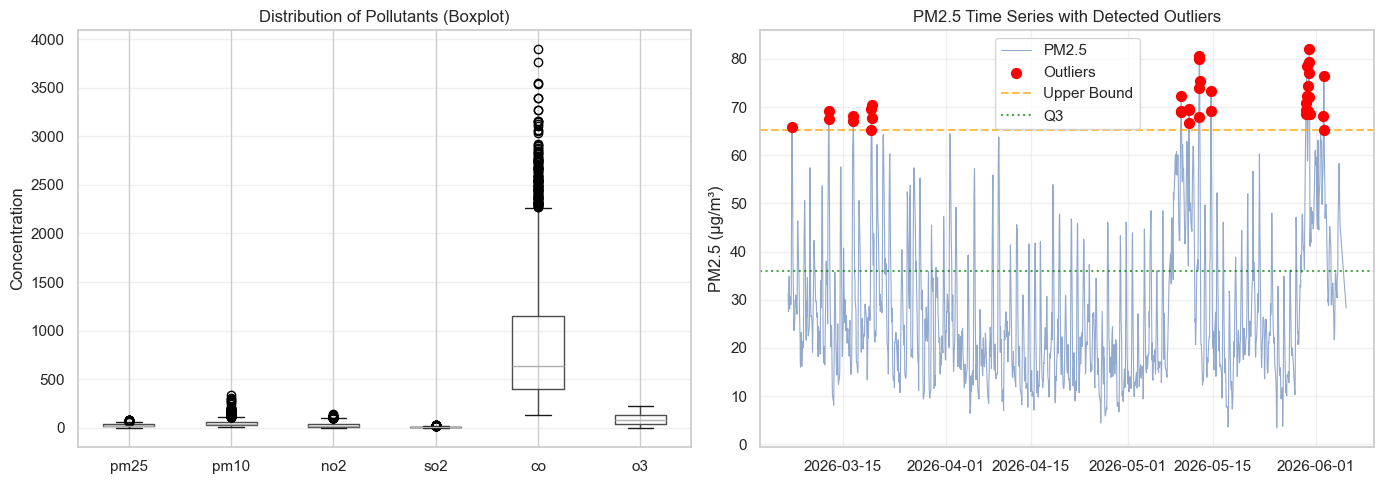

In [12]:
# IQR-based outlier detection
Q1 = df['pm25'].quantile(0.25)
Q3 = df['pm25'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['pm25'] < lower_bound) | (df['pm25'] > upper_bound)]
print(f"\n{'='*70}")
print(f"OUTLIER ANALYSIS (IQR Method)")
print(f"{'='*70}")
print(f"Lower Bound: {lower_bound:.2f} µg/m³")
print(f"Upper Bound: {upper_bound:.2f} µg/m³")
print(f"Total Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print(f"\nExtreme Pollution Events (Top 10):")
    print(outliers.nlargest(10, 'pm25')[['timestamp', 'pm25', 'temperature', 'humidity', 'wind_speed']])

# Boxplot with outliers highlighted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pollutant comparison boxplot
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
df[pollutants].boxplot(ax=axes[0])
axes[0].set_title('Distribution of Pollutants (Boxplot)')
axes[0].set_ylabel('Concentration')
axes[0].grid(axis='y', alpha=0.3)

# PM2.5 over time with outliers
axes[1].plot(df['timestamp'], df['pm25'], alpha=0.6, label='PM2.5', linewidth=0.8)
axes[1].scatter(outliers['timestamp'], outliers['pm25'], color='red', s=50, label='Outliers', zorder=5)
axes[1].axhline(y=upper_bound, color='orange', linestyle='--', label='Upper Bound', alpha=0.7)
axes[1].axhline(y=Q3, color='green', linestyle=':', label='Q3', alpha=0.7)
axes[1].set_title('PM2.5 Time Series with Detected Outliers')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Full Time-Series Visualization
Complete temporal evolution of key pollutants and weather features.


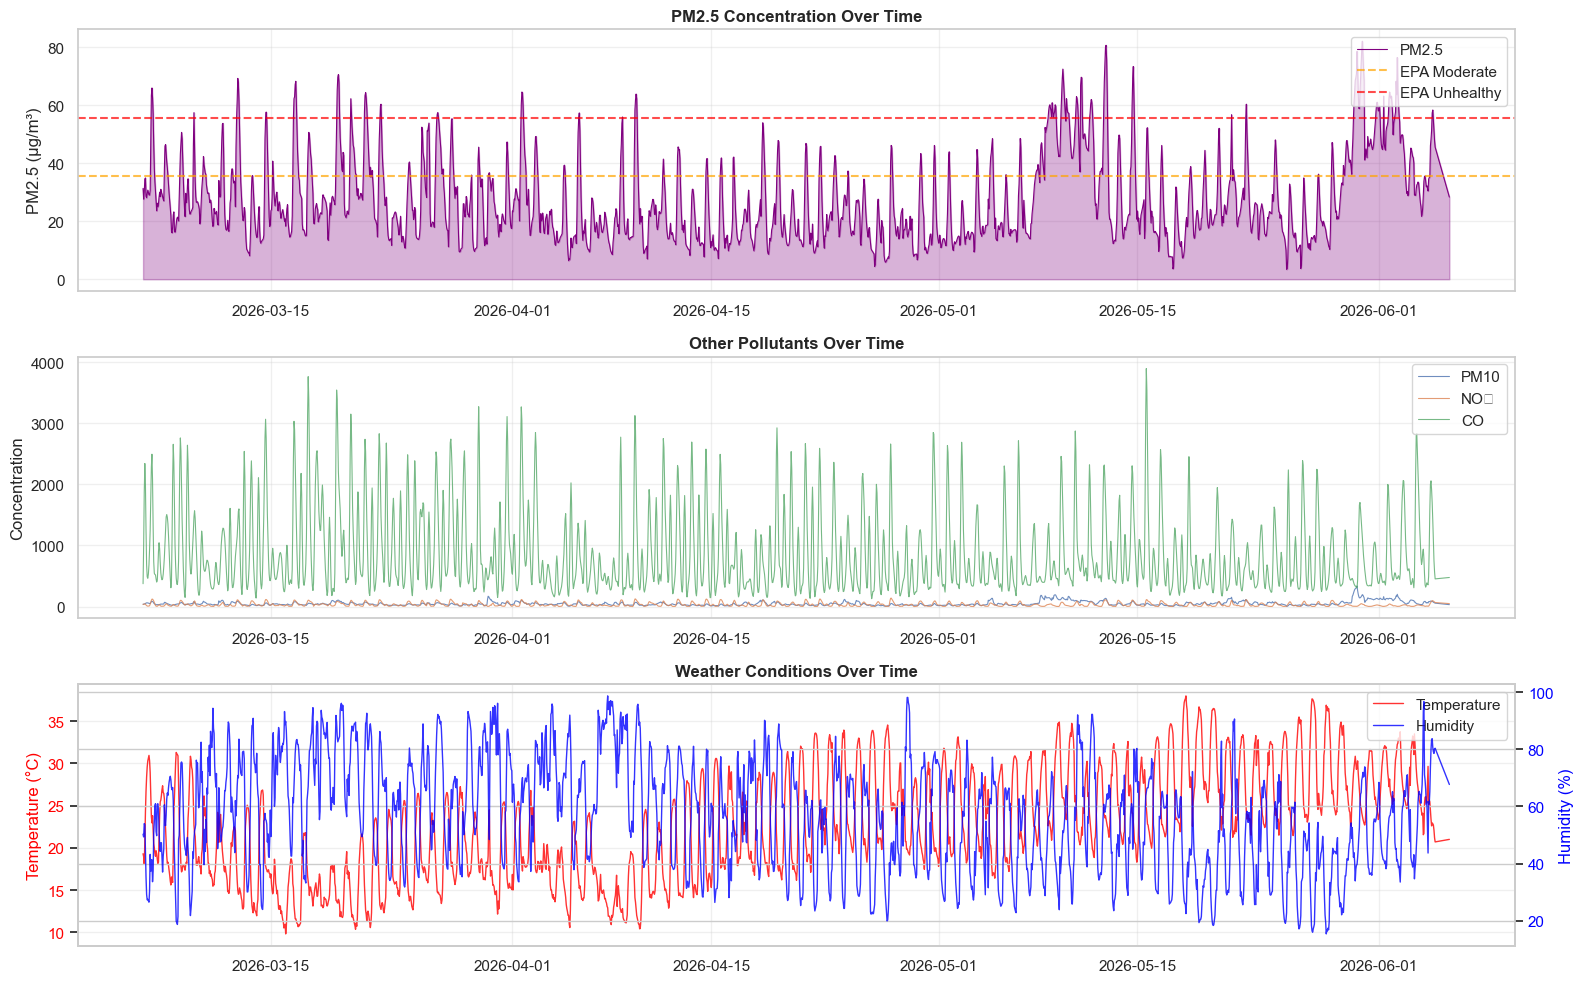


Time-Series Statistics:
  Total hours: 2185
  Date range: 2026-03-06 00:00:00+00:00 to 2026-06-05 23:00:00+00:00
  Average PM2.5: 27.58 µg/m³
  Peak PM2.5: 82.00 µg/m³ on 2026-05-30T20:00:00.000000


In [13]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# PM2.5 main target
axes[0].plot(df['timestamp'], df['pm25'], linewidth=0.8, color='purple', label='PM2.5')
axes[0].fill_between(df['timestamp'], df['pm25'], alpha=0.3, color='purple')
axes[0].axhline(y=35.4, color='orange', linestyle='--', alpha=0.7, label='EPA Moderate')
axes[0].axhline(y=55.4, color='red', linestyle='--', alpha=0.7, label='EPA Unhealthy')
axes[0].set_title('PM2.5 Concentration Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Other pollutants comparison
axes[1].plot(df['timestamp'], df['pm10'], label='PM10', linewidth=0.8, alpha=0.8)
axes[1].plot(df['timestamp'], df['no2'], label='NO₂', linewidth=0.8, alpha=0.8)
axes[1].plot(df['timestamp'], df['co'], label='CO', linewidth=0.8, alpha=0.8)
axes[1].set_title('Other Pollutants Over Time', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Concentration')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

# Weather conditions
ax2_twin = axes[2].twinx()
axes[2].plot(df['timestamp'], df['temperature'], color='red', linewidth=1, label='Temperature', alpha=0.8)
ax2_twin.plot(df['timestamp'], df['humidity'], color='blue', linewidth=1, label='Humidity', alpha=0.8)
axes[2].set_title('Weather Conditions Over Time', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Temperature (°C)', color='red')
ax2_twin.set_ylabel('Humidity (%)', color='blue')
axes[2].tick_params(axis='y', labelcolor='red')
ax2_twin.tick_params(axis='y', labelcolor='blue')
axes[2].grid(alpha=0.3)

# Add legends
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nTime-Series Statistics:")
print(f"  Total hours: {len(df)}")
print(f"  Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"  Average PM2.5: {df['pm25'].mean():.2f} µg/m³")
print(f"  Peak PM2.5: {df['pm25'].max():.2f} µg/m³ on {df[df['pm25'] == df['pm25'].max()]['timestamp'].values[0]}")
